In [1]:
#导入常用库
import sys
import pandas as pd
import os
import random
import shutil
import sklearn
import scipy
import numpy as np
import radiomics  #这个库专门用来提取特征
import SimpleITK as sitk  #读取nii文件
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV#导入Lasso工具包LassoCV
from sklearn.preprocessing import StandardScaler#标准化工具包StandardScaler
import seaborn as sns
from sklearn import metrics
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
model_name='model_forest1.model'

# radio_datapath=r"E:\liuzhou_breastcancer\radiology\washout-subregiuon.csv"
radio_datapath = r"E:\liuzhou_breastcancer\radiology\subregion_all_radiology_2025-04-15.csv"
in_datapath = r"E:\liuzhou_breastcancer\radiology\washin_radiology_2024-10-30.csv"
out_datapath = r"E:\liuzhou_breastcancer\radiology\washout_radiology_2024-10-31.csv"

radio_data=pd.read_csv(radio_datapath)
in_data=pd.read_csv(in_datapath)
out_data=pd.read_csv(out_datapath)

radio_data.head()

,index,patient_name,label_name,grade,diagnostics_Versions_PyRadiomics,diagnostics_Versions_Numpy,diagnostics_Versions_SimpleITK,diagnostics_Versions_PyWavelet,diagnostics_Versions_Python,diagnostics_Configuration_Settings,...,wavelet3-LLL_gldm_GrayLevelNonUniformity,wavelet3-LLL_gldm_GrayLevelVariance,wavelet3-LLL_gldm_HighGrayLevelEmphasis,wavelet3-LLL_gldm_LargeDependenceEmphasis,wavelet3-LLL_gldm_LargeDependenceHighGrayLevelEmphasis,wavelet3-LLL_gldm_LargeDependenceLowGrayLevelEmphasis,wavelet3-LLL_gldm_LowGrayLevelEmphasis,wavelet3-LLL_gldm_SmallDependenceEmphasis,wavelet3-LLL_gldm_SmallDependenceHighGrayLevelEmphasis,wavelet3-LLL_gldm_SmallDependenceLowGrayLevelEmphasis
0,0,1,Untitled.nii.gz,0,v3.0.1,2.2.3,2.4.1,1.8.0,3.10.16,"{'minimumROIDimensions': 2, 'minimumROISize': ...",...,16.394737,7.332237,40.394737,21.315789,1156.210526,2.223632,0.137005,0.165244,4.380284,0.031207
1,1,10,Untitled.nii.gz,0,v3.0.1,2.2.3,2.4.1,1.8.0,3.10.16,"{'minimumROIDimensions': 2, 'minimumROISize': ...",...,167.376448,3.780776,40.175676,92.918919,4108.081081,2.620304,0.053798,0.075771,2.077739,0.009894
2,2,101,101-shenmengyun=2021.12.07.nii.gz,0,v3.0.1,2.2.3,2.4.1,1.8.0,3.10.16,"{'minimumROIDimensions': 2, 'minimumROISize': ...",...,100.611111,2.136334,20.994444,68.000000,1914.750000,3.886214,0.086899,0.046295,0.635624,0.006259
3,3,102,Untitled.nii.gz,0,v3.0.1,2.2.3,2.4.1,1.8.0,3.10.16,"{'minimumROIDimensions': 2, 'minimumROISize': ...",...,1482.693231,5.000130,43.275607,224.253384,13261.414559,5.578870,0.059430,0.037008,0.936772,0.005418
4,4,103,Untitled.nii.gz,0,v3.0.1,2.2.3,2.4.1,1.8.0,3.10.16,"{'minimumROIDimensions': 2, 'minimumROISize': ...",...,68.572519,2.443538,24.292621,60.603053,1629.463104,3.363029,0.074064,0.068772,1.312268,0.011229


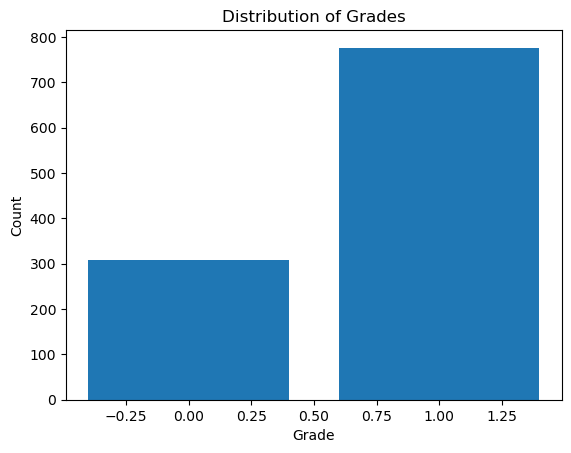

grade
1    776
0    308
Name: count, dtype: int64


In [3]:
# 查看总数据类别是否平衡
fig, ax = plt.subplots()
# sns.set()
# ax = sns.countplot(x='grade',hue='grade',data=radio_data)
# print(radio_data['grade'].value_counts())

# 计算每个类别的计数
grade_counts = radio_data['grade'].value_counts()

# 绘制条形图
plt.bar(grade_counts.index, grade_counts.values)

# 添加标签和标题
plt.xlabel('Grade')
plt.ylabel('Count')
plt.title('Distribution of Grades')

# 显示图表
plt.show()

# 打印类别计数
print(grade_counts)

In [4]:
from pandas.core.common import random_state

#查看总体数据情况
print("一共有{}行特征数据".format(radio_data.shape[0]))
# print("一共有{}列不同特征".format(radio_data.shape[1]))
#再把特征值数据和标签数据分开
# x1=radio_data[radio_data.columns[3:-46]]
# x2=radio_data[radio_data.columns[-23:-4]]
# x1 = x1.reset_index(drop=True)
# x2 = x2.reset_index(drop=True)

x1 = radio_data[radio_data.columns[4:]]
x2 = in_data[in_data.columns[4:]]
x3 = out_data[out_data.columns[4:]]

x2 = x2.add_prefix('*')  # 给 x2 的列名添加前缀 "x2_"
x3 = x3.add_prefix('**')  # 给 x3 的列名添加前缀 "x3_"

# x = pd.concat([x1, x2, x3], axis=1)
# print("一共有{}列不同特征".format(x.shape[1]))
y = radio_data['grade']
# 取X的5行看看数据
# x.head()

一共有1084行特征数据


In [5]:
# 区分训练集和测试集
from sklearn.model_selection import train_test_split
from sklearn import datasets
seed=6677
# 30%用于测试集，70%用于训练集
X1_train,X1_test,y_train,y_test= train_test_split(x1,y,test_size=0.3, stratify=y, random_state=seed)
X2_train,X2_test,y_train,y_test= train_test_split(x2,y,test_size=0.3, stratify=y, random_state=seed)
X3_train,X3_test,y_train,y_test= train_test_split(x3,y,test_size=0.3, stratify=y, random_state=seed)


pd_train=pd.DataFrame(X1_train)
train_index=np.array(pd_train.index)
# np.savetxt('../../data/trian_test_csv/train.txt',train_index.astype('int'))
#
# pd_test=pd.DataFrame(X_test)
# test_index=np.array(pd_test.index)
# np.savetxt('../../data/trian_test_csv/test.txt',test_index.astype('int'))
# 打印验证是否随机
print(train_index)

[  92  688   76  409  552  876  759  179  242  442 1079  159  302   82
   13  267    7  196  106   90  499  555  766  383  607  222  556  428
  270 1068   79  237  105  359  386  475  936 1061   87  709  316  210
  679  213  309  191  177 1062  244 1016  509  551  557  255  370  109
  770  837  365   47   98  496  126  728  321  526  243  353  150 1063
  622  104  562 1032  992  274  957  368  510  585  381  258  494  502
   23  944  665  901  114  363  338  379  928  730    1  911  318  564
  229  706  726  703    8  984  356  963   29   15  236  345  541  650
  821  165  671  632  158  195  991  171  214  659  872  816 1080  199
  506  910  862  325  959  977  758   99  262  802   63  897  789  256
  376   68  528 1027  920  625  540  248  369  154   26   96 1004  989
  463  468  151   34  891  103  680  779  599  505 1078   30  692  432
  352  358  487  591  656  822  651  272  533  669   58  112  974  186
  937  574  273  958  918  813  259   52  971  218  640  410 1000  569
  934 

# 特征筛选方法

In [6]:
# T检验特诊筛选

#通过T检验从106个特征筛选
from scipy.stats import levene, ttest_ind
counts = 0
columns_index1 =[]
columns_index2 =[]
columns_index3 =[]
# print(X_train[y_train==0])
for column_name in X1_train.columns[1:]:
    # print(column_name)
    print("\033[1;31;40m"+column_name+"\033[0m")
    try:
        if levene(X1_train[y_train==0][column_name], X1_train[y_train==1][column_name])[1] > 0.05:
            if ttest_ind(X1_train[y_train==0][column_name], X1_train[y_train==1][column_name],equal_var=True)[1] < 0.05:
                columns_index1.append(column_name)
        else:
            if ttest_ind(X1_train[y_train==0][column_name], X1_train[y_train==1][column_name],equal_var=False)[1] < 0.05:
                columns_index1.append(column_name)
    except Exception as ex:
        print("出现如下异常: %s"%ex)
        continue

print("筛选后剩下的特征数：{}个".format(len(columns_index1)))


for column_name in X2_train.columns[1:]:
    # print(column_name)
    print("\033[1;31;40m"+column_name+"\033[0m")
    try:
        if levene(X2_train[y_train==0][column_name], X2_train[y_train==1][column_name])[1] > 0.05:
            if ttest_ind(X2_train[y_train==0][column_name], X2_train[y_train==1][column_name],equal_var=True)[1] < 0.05:
                columns_index2.append(column_name)
        else:
            if ttest_ind(X2_train[y_train==0][column_name], X2_train[y_train==1][column_name],equal_var=False)[1] < 0.05:
                columns_index2.append(column_name)
    except Exception as ex:
        print("出现如下异常: %s"%ex)
        continue

print("筛选后剩下的特征数：{}个".format(len(columns_index2)))

for column_name in X3_train.columns[1:]:
    # print(column_name)
    print("\033[1;31;40m"+column_name+"\033[0m")
    try:
        if levene(X3_train[y_train==0][column_name], X3_train[y_train==1][column_name])[1] > 0.05:
            if ttest_ind(X3_train[y_train==0][column_name], X3_train[y_train==1][column_name],equal_var=True)[1] < 0.05:
                columns_index3.append(column_name)
        else:
            if ttest_ind(X3_train[y_train==0][column_name], X3_train[y_train==1][column_name],equal_var=False)[1] < 0.05:
                columns_index3.append(column_name)
    except Exception as ex:
        print("出现如下异常: %s"%ex)
        continue



print("筛选后剩下的特征数：{}个".format(len(columns_index3)))








diagnostics_Versions_Numpy
出现如下异常: ufunc 'divide' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''
diagnostics_Versions_SimpleITK
出现如下异常: ufunc 'divide' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''
diagnostics_Versions_PyWavelet
出现如下异常: ufunc 'divide' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''
diagnostics_Versions_Python
出现如下异常: ufunc 'divide' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''
diagnostics_Configuration_Settings
出现如下异常: ufunc 'divide' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''
diagnostics_Configuration_Enabled

In [ ]:
print(columns_index)

['diagnostics_Image-original_Mean', 'diagnostics_Mask-original_VoxelNum', 'original_shape_Flatness', 'original_shape_LeastAxisLength', 'original_shape_MajorAxisLength', 'original_shape_Maximum2DDiameterColumn', 'original_shape_Maximum2DDiameterRow', 'original_shape_Maximum2DDiameterSlice', 'original_shape_Maximum3DDiameter', 'original_shape_MeshVolume', 'original_shape_MinorAxisLength', 'original_shape_Sphericity', 'original_shape_SurfaceArea', 'original_shape_SurfaceVolumeRatio', 'original_shape_VoxelVolume', 'original_firstorder_Energy', 'original_firstorder_Entropy', 'original_firstorder_InterquartileRange', 'original_firstorder_MeanAbsoluteDeviation', 'original_firstorder_Mean', 'original_firstorder_RobustMeanAbsoluteDeviation', 'original_firstorder_RootMeanSquared', 'original_firstorder_TotalEnergy', 'original_firstorder_Variance', 'original_glcm_DifferenceEntropy', 'original_glcm_JointEntropy', 'original_glcm_SumEntropy', 'original_glrlm_GrayLevelNonUniformity', 'original_glrlm_L

In [7]:
columns_index2.remove('*diagnostics_Image-original_Maximum')

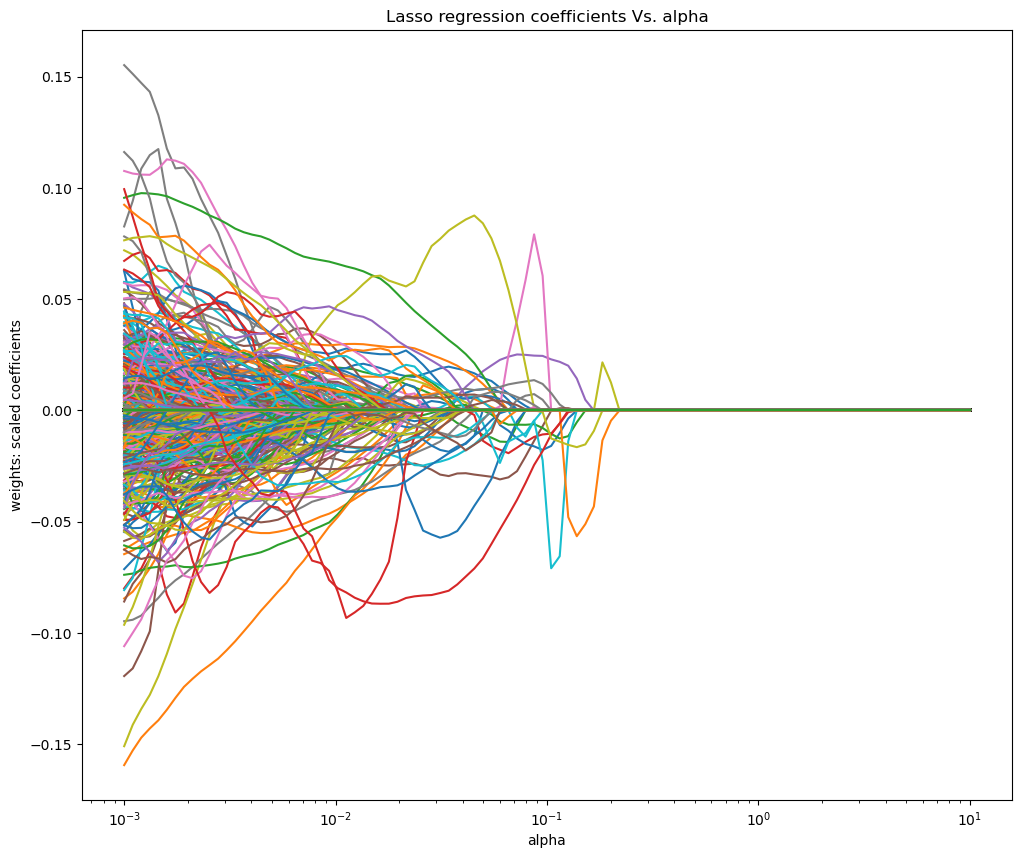

In [9]:
from sklearn.linear_model import Lasso

# 标准化数据
scaler = StandardScaler()
# columns_index.remove('diagnostics_Image-original_Maximum')
X_train_scaled = scaler.fit_transform(X_train.loc[:, columns_index])

alpha_lasso = 10**np.linspace(-3,1,100)
lasso = Lasso()
coefs_lasso = []

for i in alpha_lasso:
    lasso.set_params(alpha = i)
    lasso.fit(X_train_scaled, y_train)
    coefs_lasso.append(lasso.coef_)

plt.figure(figsize=(12,10))
ax = plt.gca()
ax.plot(alpha_lasso, coefs_lasso)
ax.set_xscale('log')
plt.axis('tight')
plt.xlabel('alpha')
plt.ylabel('weights: scaled coefficients')
plt.title('Lasso regression coefficients Vs. alpha')
# plt.legend(y)
plt.show()

In [22]:
# coef = pd.Series(Lasso.coef_, index=columns_index)
# print(coef[coef !=0])

In [81]:
# habitat特征
# 再把特征值数据和标签数据分开
x = X1_train.loc[:,columns_index1]
y = y_train
#先保存X的列名
columnNames = x.columns

lassoCV_x = x.astype(np.float32)#把x数据转换成np.float格式
lassoCV_y = y

standardscaler = StandardScaler()
lassoCV_x = standardscaler.fit_transform(lassoCV_x)#对x进行均值-标准差归一化
lassoCV_x = pd.DataFrame(lassoCV_x,columns=columnNames)#转 DataFrame 格式

# 形成5为底的指数函数
# 5**（-3） ~  5**（-2）
alpha_range = np.logspace(-4,0,150,base=5)
#alpha_range在这个参数范围里挑出aplpha进行训练，cv是把数据集分5分，进行交叉验证，max_iter是训练1000轮
lassoCV_model = LassoCV(alphas=alpha_range,cv=5,max_iter=1000)
#进行训练
lassoCV_model.fit(lassoCV_x,lassoCV_y)

#打印训练找出来的入值
print(lassoCV_model.alpha_)
# print("Coefficient of the model:{}".format(lassoCV_model.coef_) )
# print("intercept of the model:{}".format(lassoCV_model.intercept_))

coef1 = pd.Series(lassoCV_model.coef_, index=columnNames)
print("从原来{}个特征，筛选剩下{}个".format(len(columnNames),sum(coef1 !=0)))
print("分别是以下特征")
print(coef1[coef1 !=0])
index = coef1[coef1 !=0].index
lassoCV_x = lassoCV_x[index]
# lassoCV_x.head()

0.011181840072103806
从原来1783个特征，筛选剩下87个
分别是以下特征
original_shape_Flatness                              0.035668
original_shape_MajorAxisLength                      -0.010778
original_glrlm_LongRunEmphasis                      -0.010593
original_glrlm_LongRunLowGrayLevelEmphasis          -0.000283
original_glszm_SmallAreaLowGrayLevelEmphasis         0.005769
                                                       ...   
wavelet3-HHH_glszm_SmallAreaHighGrayLevelEmphasis    0.009132
wavelet3-HHH_ngtdm_Complexity                       -0.002677
wavelet3-LLL_firstorder_InterquartileRange          -0.008488
wavelet3-LLL_firstorder_Minimum                     -0.053155
wavelet3-LLL_firstorder_Uniformity                   0.007148
Length: 87, dtype: float32


In [82]:
# wash-in特征
# 再把特征值数据和标签数据分开
x = X2_train.loc[:,columns_index2]
y = y_train
#先保存X的列名
columnNames = x.columns

lassoCV_x = x.astype(np.float32)#把x数据转换成np.float格式
lassoCV_y = y

standardscaler = StandardScaler()
lassoCV_x = standardscaler.fit_transform(lassoCV_x)#对x进行均值-标准差归一化
lassoCV_x = pd.DataFrame(lassoCV_x,columns=columnNames)#转 DataFrame 格式

# 形成5为底的指数函数
# 5**（-3） ~  5**（-2）
alpha_range = np.logspace(-4,0,150,base=5)
#alpha_range在这个参数范围里挑出aplpha进行训练，cv是把数据集分5分，进行交叉验证，max_iter是训练1000轮
lassoCV_model = LassoCV(alphas=alpha_range,cv=5,max_iter=1000)
#进行训练
lassoCV_model.fit(lassoCV_x,lassoCV_y)

#打印训练找出来的入值
print(lassoCV_model.alpha_)
# print("Coefficient of the model:{}".format(lassoCV_model.coef_) )
# print("intercept of the model:{}".format(lassoCV_model.intercept_))

coef2 = pd.Series(lassoCV_model.coef_, index=columnNames)
print("从原来{}个特征，筛选剩下{}个".format(len(columnNames),sum(coef2 !=0)))
print("分别是以下特征")
print(coef2[coef2 !=0])
index = coef2[coef2 !=0].index
lassoCV_x = lassoCV_x[index]
# lassoCV_x.head()

0.005137548786033931
从原来819个特征，筛选剩下115个
分别是以下特征
*diagnostics_Image-original_Mean                        -0.087652
*diagnostics_Image-original_Minimum                     -0.026773
*original_shape_MajorAxisLength                         -0.025131
*original_shape_Maximum2DDiameterSlice                   0.041500
*original_firstorder_Maximum                            -0.085279
                                                           ...   
*wavelet-LLL_glrlm_ShortRunLowGrayLevelEmphasis          0.029233
*wavelet-LLL_glszm_GrayLevelNonUniformity                0.013980
*wavelet-LLL_glszm_GrayLevelNonUniformityNormalized      0.006536
*wavelet-LLL_glszm_SmallAreaHighGrayLevelEmphasis        0.000948
*wavelet-LLL_gldm_SmallDependenceLowGrayLevelEmphasis    0.021035
Length: 115, dtype: float32


In [83]:
# wash-out特征
# 再把特征值数据和标签数据分开
x = X3_train.loc[:,columns_index3]
y = y_train
#先保存X的列名
columnNames = x.columns

lassoCV_x = x.astype(np.float32)#把x数据转换成np.float格式
lassoCV_y = y

standardscaler = StandardScaler()
lassoCV_x = standardscaler.fit_transform(lassoCV_x)#对x进行均值-标准差归一化
lassoCV_x = pd.DataFrame(lassoCV_x,columns=columnNames)#转 DataFrame 格式

# 形成5为底的指数函数
# 5**（-3） ~  5**（-2）
alpha_range = np.logspace(-4,0,150,base=5)
#alpha_range在这个参数范围里挑出aplpha进行训练，cv是把数据集分5分，进行交叉验证，max_iter是训练1000轮
lassoCV_model = LassoCV(alphas=alpha_range,cv=5,max_iter=1000)
#进行训练
lassoCV_model.fit(lassoCV_x,lassoCV_y)

#打印训练找出来的入值
print(lassoCV_model.alpha_)
# print("Coefficient of the model:{}".format(lassoCV_model.coef_) )
# print("intercept of the model:{}".format(lassoCV_model.intercept_))

coef3 = pd.Series(lassoCV_model.coef_, index=columnNames)
print("从原来{}个特征，筛选剩下{}个".format(len(columnNames),sum(coef3 !=0)))
print("分别是以下特征")
print(coef3[coef3 !=0])
index = coef3[coef3 !=0].index
lassoCV_x = lassoCV_x[index]
# lassoCV_x.head()

0.0061067921777166155
从原来803个特征，筛选剩下104个
分别是以下特征
**original_shape_MajorAxisLength                         -0.026870
**original_shape_Maximum2DDiameterSlice                   0.006455
**original_shape_SurfaceVolumeRatio                      -0.037600
**original_firstorder_Skewness                            0.003298
**original_glcm_ClusterTendency                           0.003675
                                                            ...   
**wavelet-LLL_glszm_SizeZoneNonUniformityNormalized      -0.000343
**wavelet-LLL_ngtdm_Busyness                             -0.004022
**wavelet-LLL_gldm_HighGrayLevelEmphasis                 -0.072867
**wavelet-LLL_gldm_LargeDependenceLowGrayLevelEmphasis    0.040811
**wavelet-LLL_gldm_LowGrayLevelEmphasis                   0.000346
Length: 104, dtype: float32


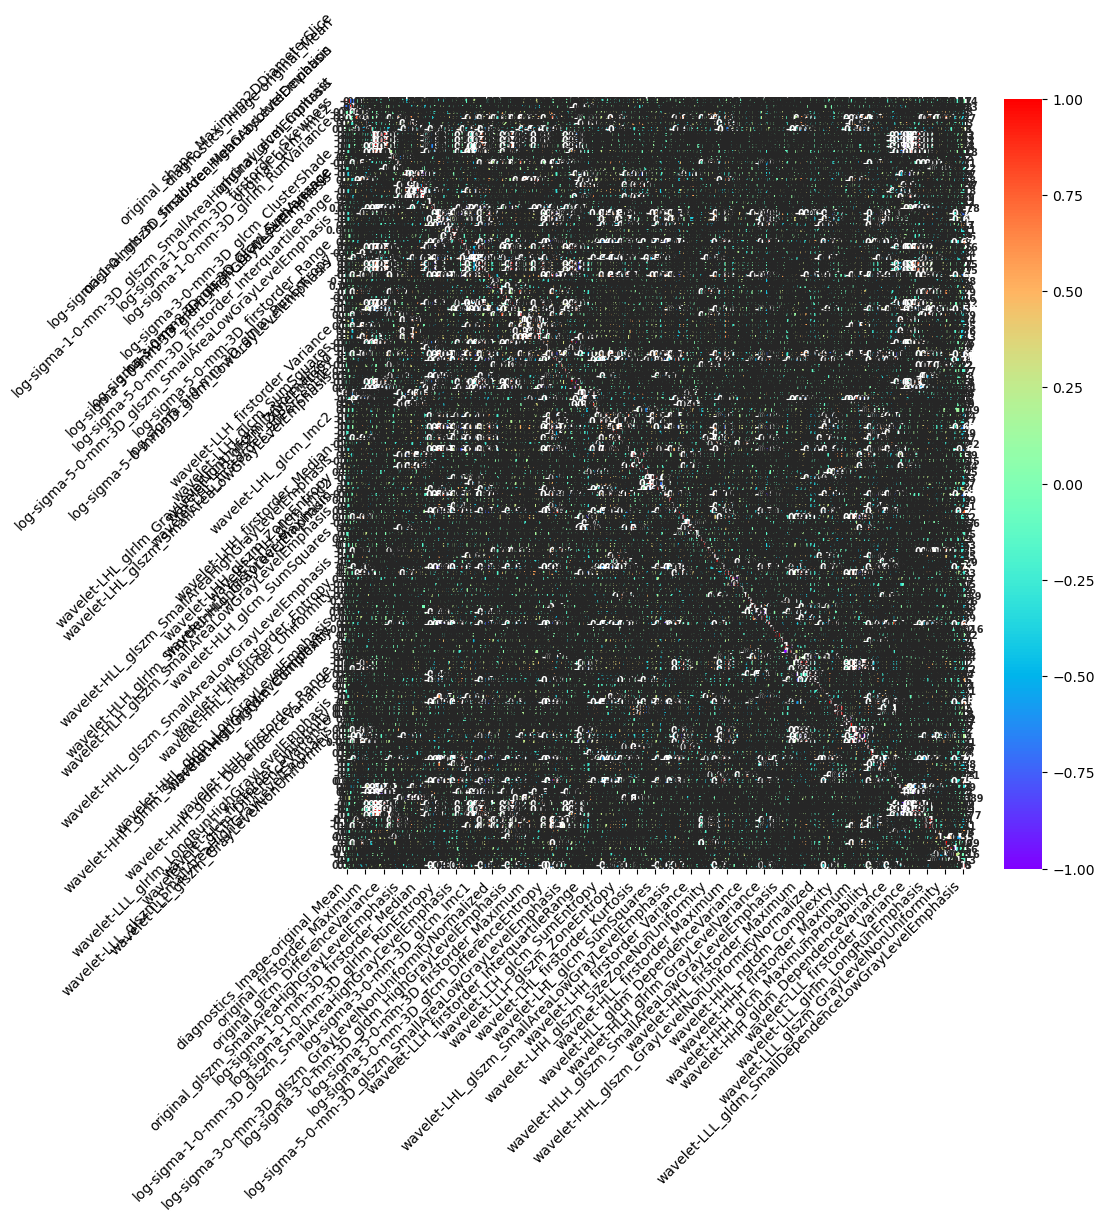

In [19]:
#绘制特征相关系数热力图
import seaborn as sns

# 根据相关性筛选
# corr_matix=lassoCV_x.corr()
# # m=~(corr_matix.mask(np.eye(len(corr_matix),dtype=bool)).abs()>0.75).any()
# # n=(corr_matix.mask(np.eye(len(corr_matix),dtype=bool)).abs()>0.75).any()
# # raw=corr_matix.loc[m,m]
# # raw_n=corr_matix.loc[n,n]
# # raw_n
# def count_high_corr(matirx, high_corr, threshold=0.5):
#     for i in range(matirx.shape[0]):
#         np_raw=np.array(matirx.iloc[i,:])
#         result=np.argwhere(np.abs(np_raw)>threshold).tolist()
#         result=[int(i[0]) for i in result]
#         high_corr[i]=len(result)
#     return high_corr
#
# hash_map=np.array(range(corr_matix.shape[0]))
# Flag=True
# high_corr=np.ones_like(hash_map)
# # corr_matix=np.array(corr_matix)
# r_list=[]
# while Flag:
#     origin_high_count=count_high_corr(corr_matix,high_corr)
#     # print(corr_matix.shape)
#     result=np.argmax(origin_high_count)
#     depend=np.max(origin_high_count)
#     if depend==1:
#         Flag=False
#         break
#     r_list.append(result)
#     # print(result)
#     high_corr[result]=0
#     # print(high_corr)
#     corr_matix.iloc[result,:]=0
#     corr_matix.iloc[:,result]=0
#     # print(corr_matix.shape)
#     # corr_matix.head()
#
# hash_map=np.delete(hash_map,r_list)
# corr_matix=lassoCV_x.corr().iloc[hash_map,hash_map]

# 画出热力图
f, ax= plt.subplots(figsize = (10, 10))
sns.heatmap(lassoCV_x.corr(),cmap='rainbow',annot=True,annot_kws={'size':7,'weight':'bold', },ax=ax)#绘制混淆矩阵
ax.set_xticklabels(ax.get_xticklabels(), rotation=45,va="top",ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=45)
plt.show()


In [25]:
# index=corr_matix.index
# lassoCV_x = lassoCV_x[index]
# coef = coef.loc[index]
# print(coef.shape)

In [85]:
weight1 = coef1[np.abs(coef1)>0.03].to_dict()
weight2 = coef2[np.abs(coef2)>0.03].to_dict()
weight3 = coef3[np.abs(coef3)>0.03].to_dict()

pd_weight1=pd.DataFrame(coef1[np.abs(coef1)>0.03])
pd_weight2=pd.DataFrame(coef2[np.abs(coef2)>0.03])
pd_weight3=pd.DataFrame(coef3[np.abs(coef3)>0.03])

print(pd_weight1.shape, pd_weight2.shape, pd_weight3.shape)

print(pd_weight1)
# weight1
# weight2
weight3

(11, 1) (32, 1) (19, 1)
                                                           0
original_shape_Flatness                             0.035668
log-sigma-5-0-mm-3D_glszm_ZoneEntropy               0.035848
wavelet-LHL_glszm_ZoneEntropy                       0.032602
wavelet2-LLH_glszm_LowGrayLevelZoneEmphasis         0.074542
wavelet2-HLH_glszm_SizeZoneNonUniformityNormalized -0.030305
wavelet3-LHL_firstorder_Kurtosis                   -0.037010
wavelet3-LHH_gldm_DependenceVariance               -0.030325
wavelet3-HLL_glcm_Idn                               0.035740
wavelet3-HHH_firstorder_Mean                        0.040572
wavelet3-HHH_glcm_Imc2                             -0.065493
wavelet3-LLL_firstorder_Minimum                    -0.053155


{'**original_shape_SurfaceVolumeRatio': -0.037600066512823105,
 '**log-sigma-1-0-mm-3D_firstorder_Uniformity': 0.03001616708934307,
 '**log-sigma-3-0-mm-3D_ngtdm_Strength': -0.03358827158808708,
 '**log-sigma-5-0-mm-3D_glcm_ClusterShade': -0.04058266803622246,
 '**log-sigma-5-0-mm-3D_glszm_HighGrayLevelZoneEmphasis': 0.04479624703526497,
 '**log-sigma-5-0-mm-3D_gldm_DependenceVariance': -0.07834448665380478,
 '**wavelet-LLH_glcm_ClusterShade': -0.04945458471775055,
 '**wavelet-LHL_firstorder_InterquartileRange': 0.049564607441425323,
 '**wavelet-LHL_glrlm_HighGrayLevelRunEmphasis': 0.0318472757935524,
 '**wavelet-LHL_glrlm_RunVariance': 0.04481733590364456,
 '**wavelet-LHH_glcm_Imc2': -0.03267887234687805,
 '**wavelet-HLL_firstorder_Maximum': 0.040224190801382065,
 '**wavelet-HHL_firstorder_InterquartileRange': 0.047817159444093704,
 '**wavelet-HHL_glcm_Autocorrelation': -0.049082525074481964,
 '**wavelet-HHH_glszm_ZoneEntropy': 0.0518452487885952,
 '**wavelet-HHH_gldm_SmallDependenceH

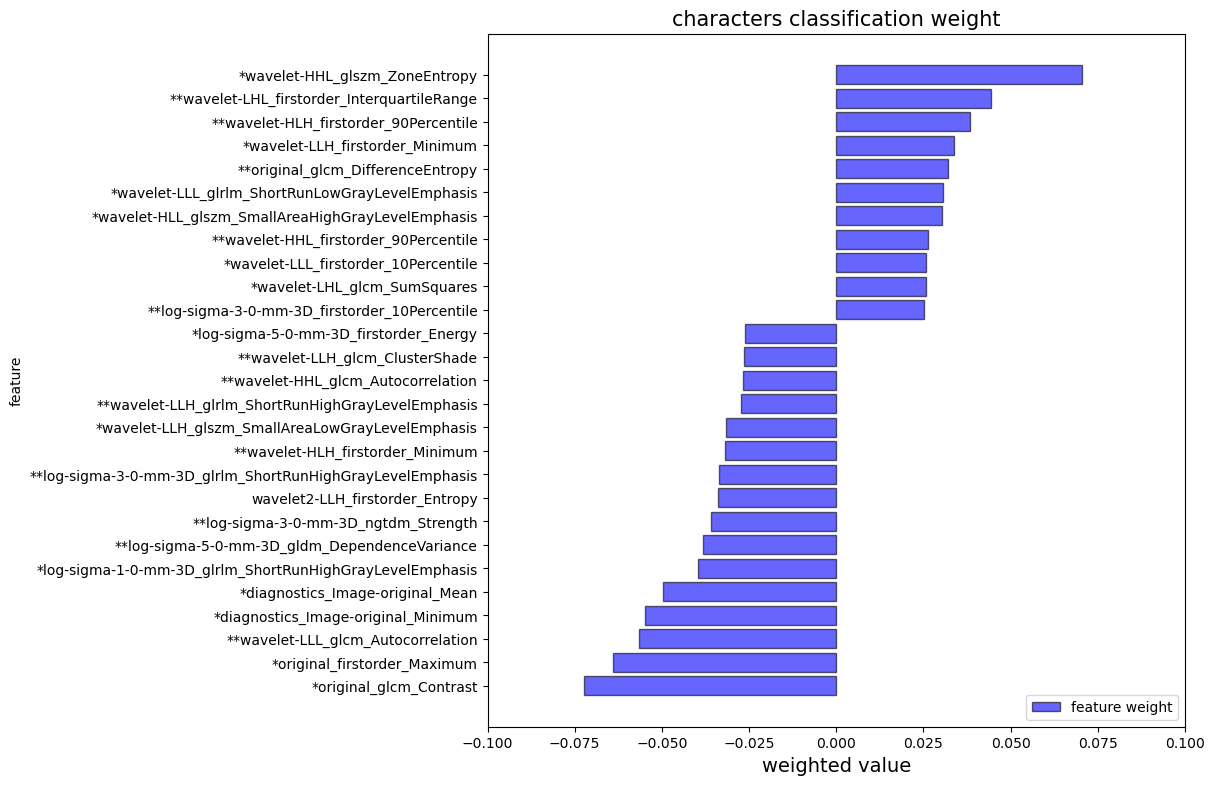

,0
*original_glcm_Contrast,-0.072436
*original_firstorder_Maximum,-0.063898
**wavelet-LLL_glcm_Autocorrelation,-0.056572
*diagnostics_Image-original_Minimum,-0.054925
*diagnostics_Image-original_Mean,-0.049653
*log-sigma-1-0-mm-3D_glrlm_ShortRunHighGrayLevelEmphasis,-0.039765
**log-sigma-5-0-mm-3D_gldm_DependenceVariance,-0.038207
**log-sigma-3-0-mm-3D_ngtdm_Strength,-0.035982
wavelet2-LLH_firstorder_Entropy,-0.034035
**log-sigma-3-0-mm-3D_glrlm_ShortRunHighGrayLevelEmphasis,-0.033683


In [13]:
#画一个特征系数的柱状图
weight = coef[np.abs(coef)>0.025].to_dict()
#根据值大小排列一下
weight = dict(sorted(weight.items(),key=lambda x:x[1],reverse=False))
plt.figure(figsize=(9,9))#设置画布的尺寸
plt.title('characters classification weight',fontsize=15)#标题，并设定字号大小
plt.xlabel(u'weighted value',fontsize=14)#设置x轴，并设定字号大小
plt.ylabel(u'feature')
plt.barh(range(len(weight.values())), list(weight.values()),tick_label = list(weight.keys()),alpha=0.6, facecolor = 'blue', edgecolor = 'black', label='feature weight')
plt.xlim([-0.1,0.1])
plt.legend(loc=4)#图例展示位置，数字代表第几象限
plt.show()
pd_weight=pd.DataFrame(coef[np.abs(coef)>0.025])
pd_weight=pd_weight.sort_values(by=0)
pd_weight

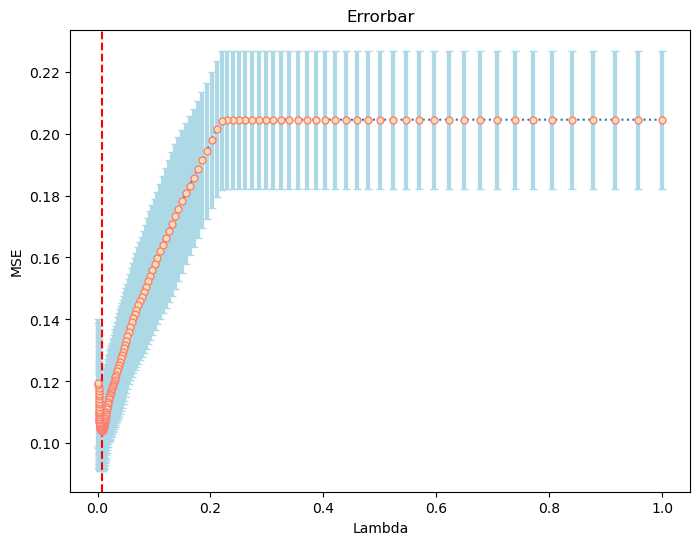

In [14]:
#绘制误差棒图
MSEs = lassoCV_model.mse_path_
mse = list()
std = list()
for m in MSEs:
    mse.append(np.mean(m))
    std.append(np.std(m))

plt.figure(figsize=(8,6))
plt.errorbar(lassoCV_model.alphas_, mse, std,fmt='o:',ecolor='lightblue',
			elinewidth=3,ms=5,mfc='wheat',mec='salmon',capsize=3)
plt.axvline(lassoCV_model.alpha_, color='red', ls='--')
plt.title('Errorbar')
plt.xlabel('Lambda')
plt.ylabel('MSE')
plt.show()

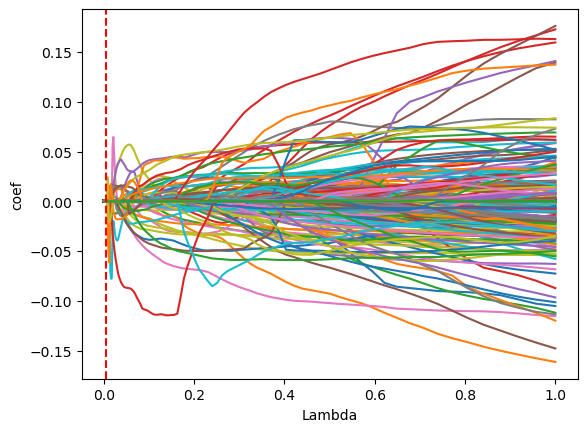

In [86]:
#再把特征值数据和标签数据分开
x1 = X1_train.loc[:,columns_index1]
x2 = X2_train.loc[:,columns_index2]
x3 = X3_train.loc[:,columns_index3]
y = y_train
#先保存X的列名
columnNames = x.columns
lassoCV_x = x.astype(np.float32)#把x数据转换成np.float格式
lassoCV_y = y
lassoCV_x = standardscaler.transform(lassoCV_x)#对x进行均值-标准差归一化
lassoCV_x = pd.DataFrame(lassoCV_x,columns=columnNames)#转 DataFrame 格式
coefs = lassoCV_model.path(lassoCV_x,lassoCV_y, alphas=alpha_range, max_iter=1000)[1].T
plt.plot(lassoCV_model.alphas,coefs,'-')
plt.axvline(lassoCV_model.alpha_, color='red', ls='--')
plt.xlabel('Lambda')
plt.ylabel('coef')
plt.show()

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.datasets import make_moons, make_circles, make_classification
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.inspection import DecisionBoundaryDisplay

In [96]:
from sklearn.model_selection import train_test_split #分割训练集和验证集
from sklearn.ensemble import RandomForestClassifier #导入随机森林分类器
import joblib #用来保存 sklearn 训练好的模型
#把数据分成训练集和验证集，7：3比例
index_1 = pd_weight1.index
rforest_x1 = x1[index_1]
index_2 = pd_weight2.index
rforest_x2 = x2[index_2]
index_3 = pd_weight3.index
rforest_x3 = x3[index_3]

rforest_x = pd.concat([rforest_x1,rforest_x2,rforest_x3],axis=1)

print(rforest_x)
rforest_y = y
standardscaler = StandardScaler()
rforest_x = standardscaler.fit_transform(rforest_x)#对x进行均值-标准差归一化
x1_train,x1_test, y1_train, y1_test = train_test_split(rforest_x,rforest_y,test_size=0.2, stratify=y, random_state=44)
seed=42
# model_forest = RandomForestClassifier(n_estimators=200,max_depth=13,max_features=1,random_state=seed).fit(x1_train,y1_train)
model_forest = SVC(kernel="linear", C=0.06,probability=True).fit(x1_train,y1_train)
# model_forest = MLPClassifier(alpha=0.1, max_iter=1000).fit(x1_train,y1_train)
score = model_forest.score(x1_test, y1_test)
print("在验证集上的准确率：{}".format(score))
#把随机森林的模型保存下来
model_path='./model'
model_name = 'in_out_sub_1_SVC0422.model'
if not os.path.exists(model_path):
    os.makedirs(model_path)
joblib.dump(model_forest, model_path+'/'+model_name)

     original_shape_Flatness  log-sigma-5-0-mm-3D_glszm_ZoneEntropy  \
92                  0.584552                          -3.203427e-16   
688                 0.772854                           2.910371e+00   
76                  0.169652                          -3.203427e-16   
409                 0.588020                           3.470108e+00   
552                 0.653874                           3.236857e+00   
..                       ...                                    ...   
563                 0.347797                           3.703107e+00   
603                 0.650625                           2.925173e+00   
176                 0.684760                          -3.203427e-16   
993                 0.513850                           1.378783e+00   
476                 0.600250                           3.540441e+00   

     wavelet-LHL_glszm_ZoneEntropy  \
92                        1.000000   
688                       2.350209   
76                        2.00000

['./model/in_out_sub_1_SVC0422.model']

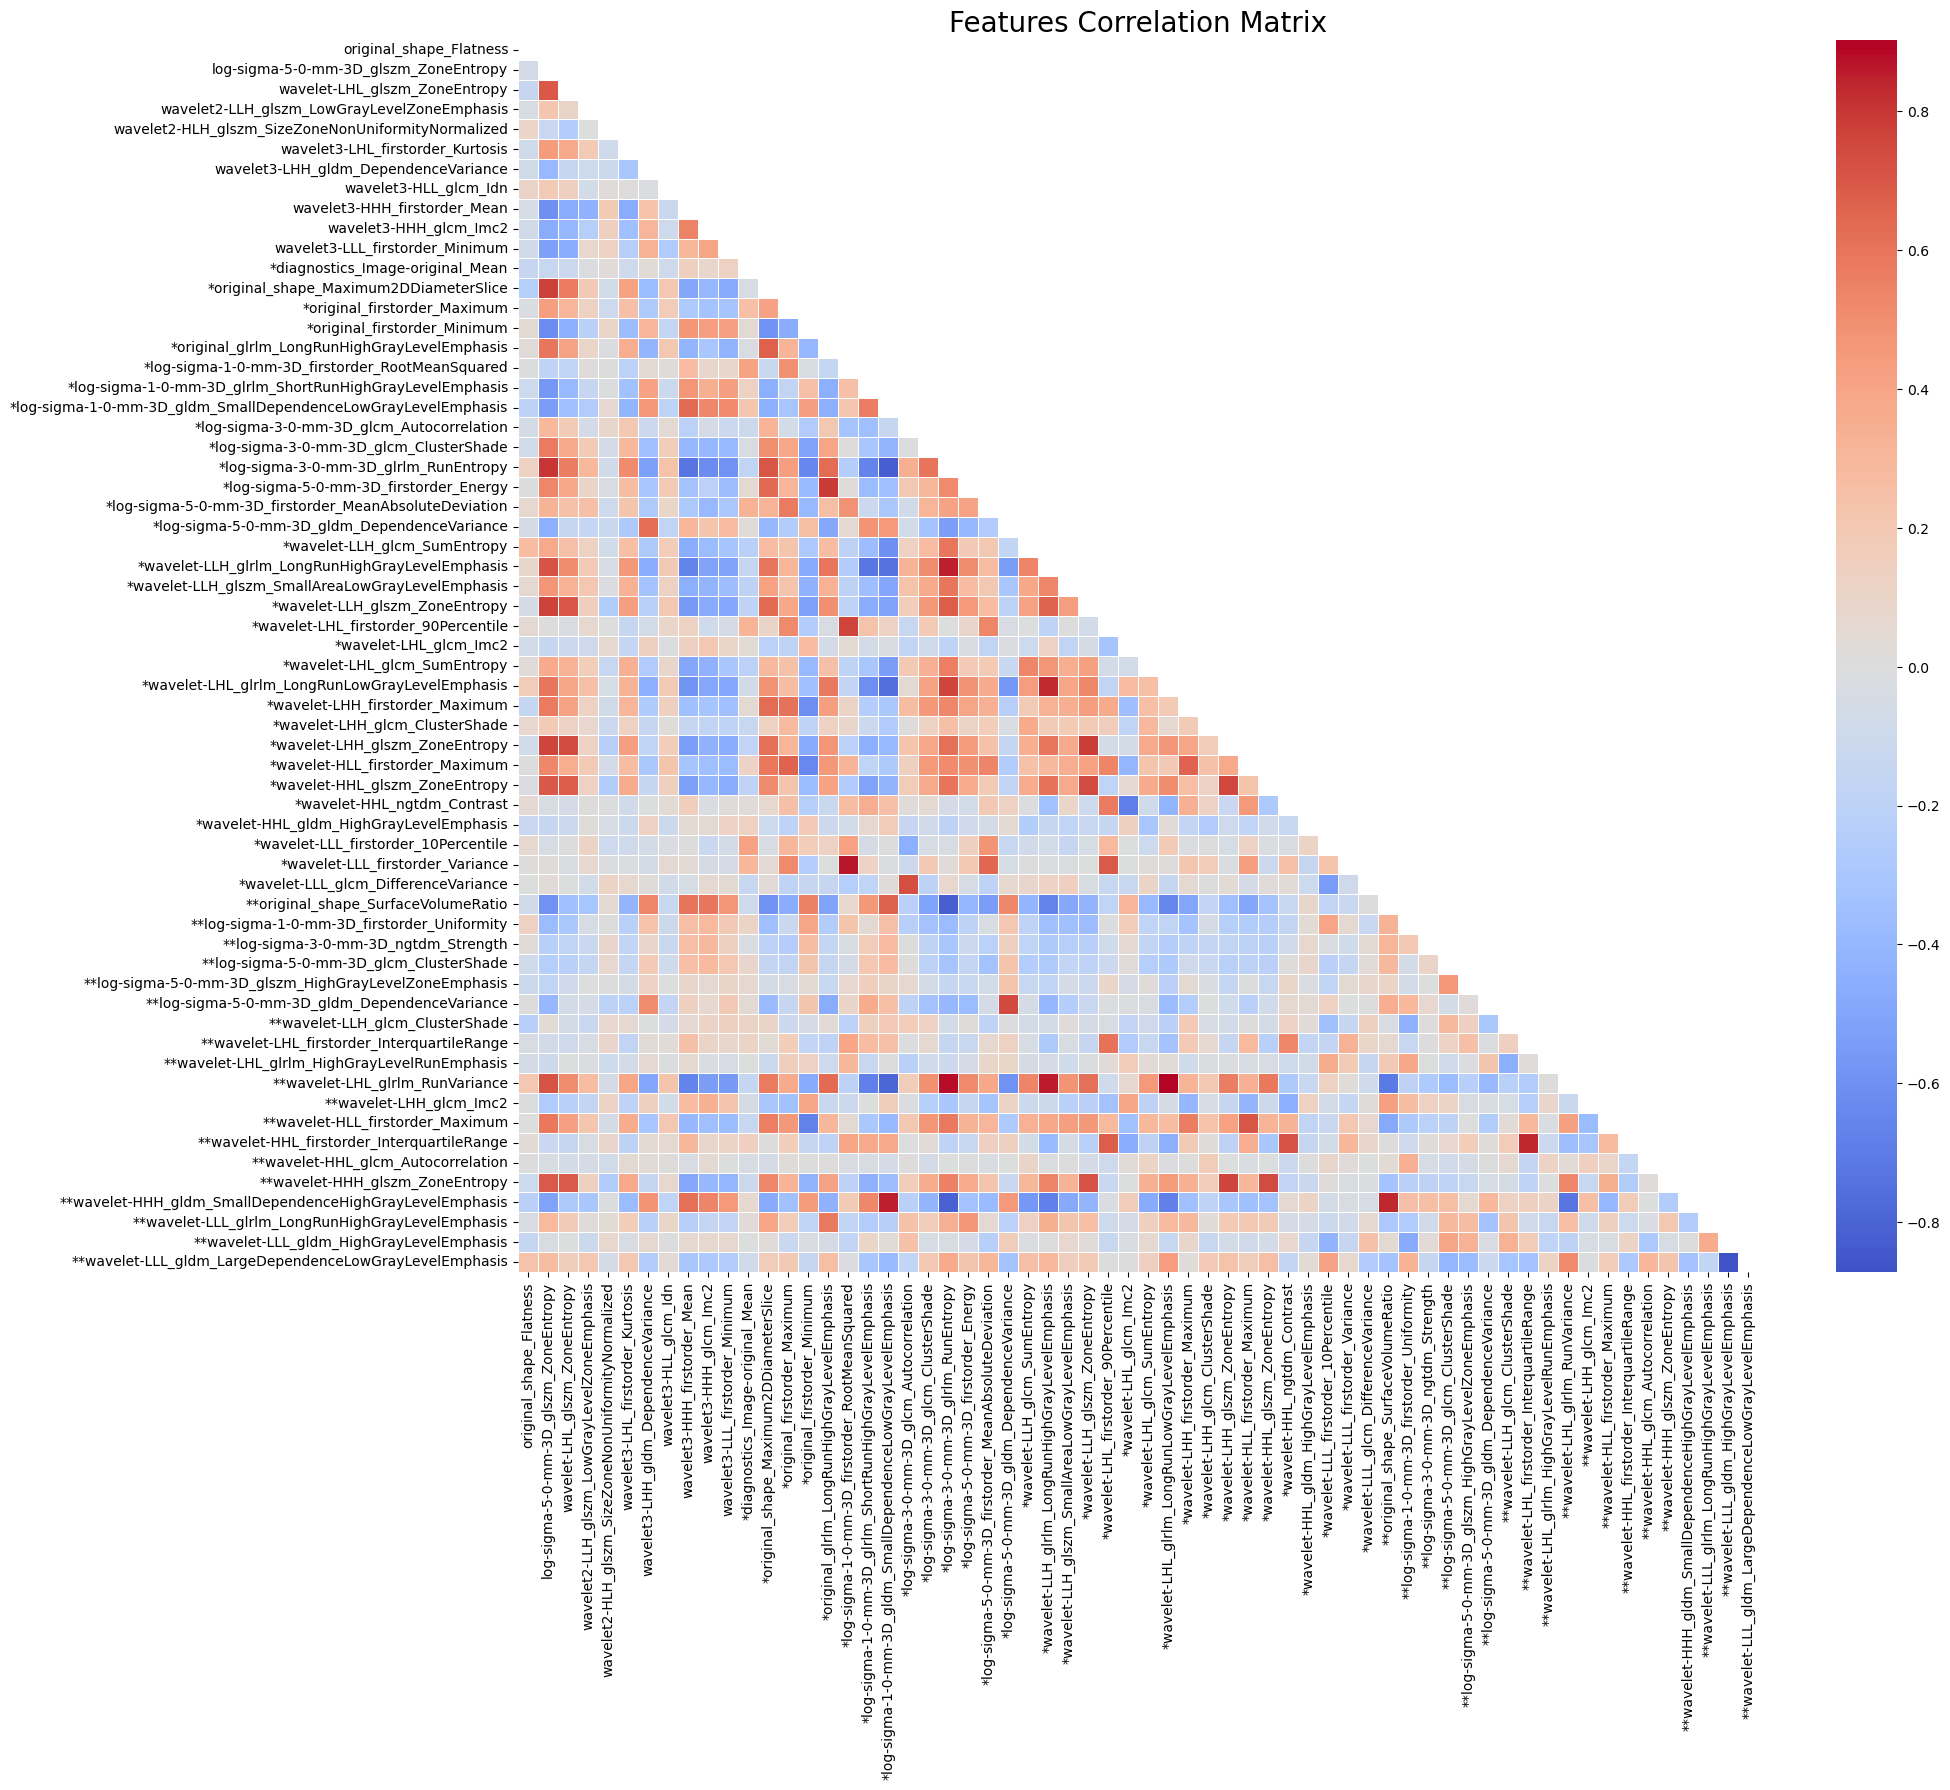

In [88]:
from sklearn.preprocessing import StandardScaler

df_col = pd.concat([rforest_x1,rforest_x2,rforest_x3],axis=1)
standardscaler.fit_transform(df_col)

corr_matrix = df_col.corr()

# 绘制热力图 (过滤|r|>0.8高相关对)
plt.figure(figsize=(20,16))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # 仅显示下三角
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0, 
            annot=False, linewidths=0.5)
plt.title("Features Correlation Matrix", fontsize=20)
plt.show()


[('log-sigma-5-0-mm-3D_glszm_ZoneEntropy', '*original_shape_Maximum2DDiameterSlice', np.float64(0.7732446951307939)), ('log-sigma-5-0-mm-3D_glszm_ZoneEntropy', '*log-sigma-3-0-mm-3D_glrlm_RunEntropy', np.float64(0.8047423685692564)), ('log-sigma-5-0-mm-3D_glszm_ZoneEntropy', '*wavelet-LLH_glrlm_LongRunHighGrayLevelEmphasis', np.float64(0.7098477290471505)), ('log-sigma-5-0-mm-3D_glszm_ZoneEntropy', '*wavelet-LLH_glszm_ZoneEntropy', np.float64(0.7657848797000678)), ('log-sigma-5-0-mm-3D_glszm_ZoneEntropy', '*wavelet-LHH_glszm_ZoneEntropy', np.float64(0.7585247027243897)), ('log-sigma-5-0-mm-3D_glszm_ZoneEntropy', '**wavelet-LHL_glrlm_RunVariance', np.float64(0.7116963176770893)), ('wavelet-LHL_glszm_ZoneEntropy', '*wavelet-LLH_glszm_ZoneEntropy', np.float64(0.7044557449162282)), ('wavelet-LHL_glszm_ZoneEntropy', '*wavelet-LHH_glszm_ZoneEntropy', np.float64(0.7391944130577212)), ('wavelet3-HHH_firstorder_Mean', '*log-sigma-3-0-mm-3D_glrlm_RunEntropy', np.float64(-0.7276896462284196)), ('

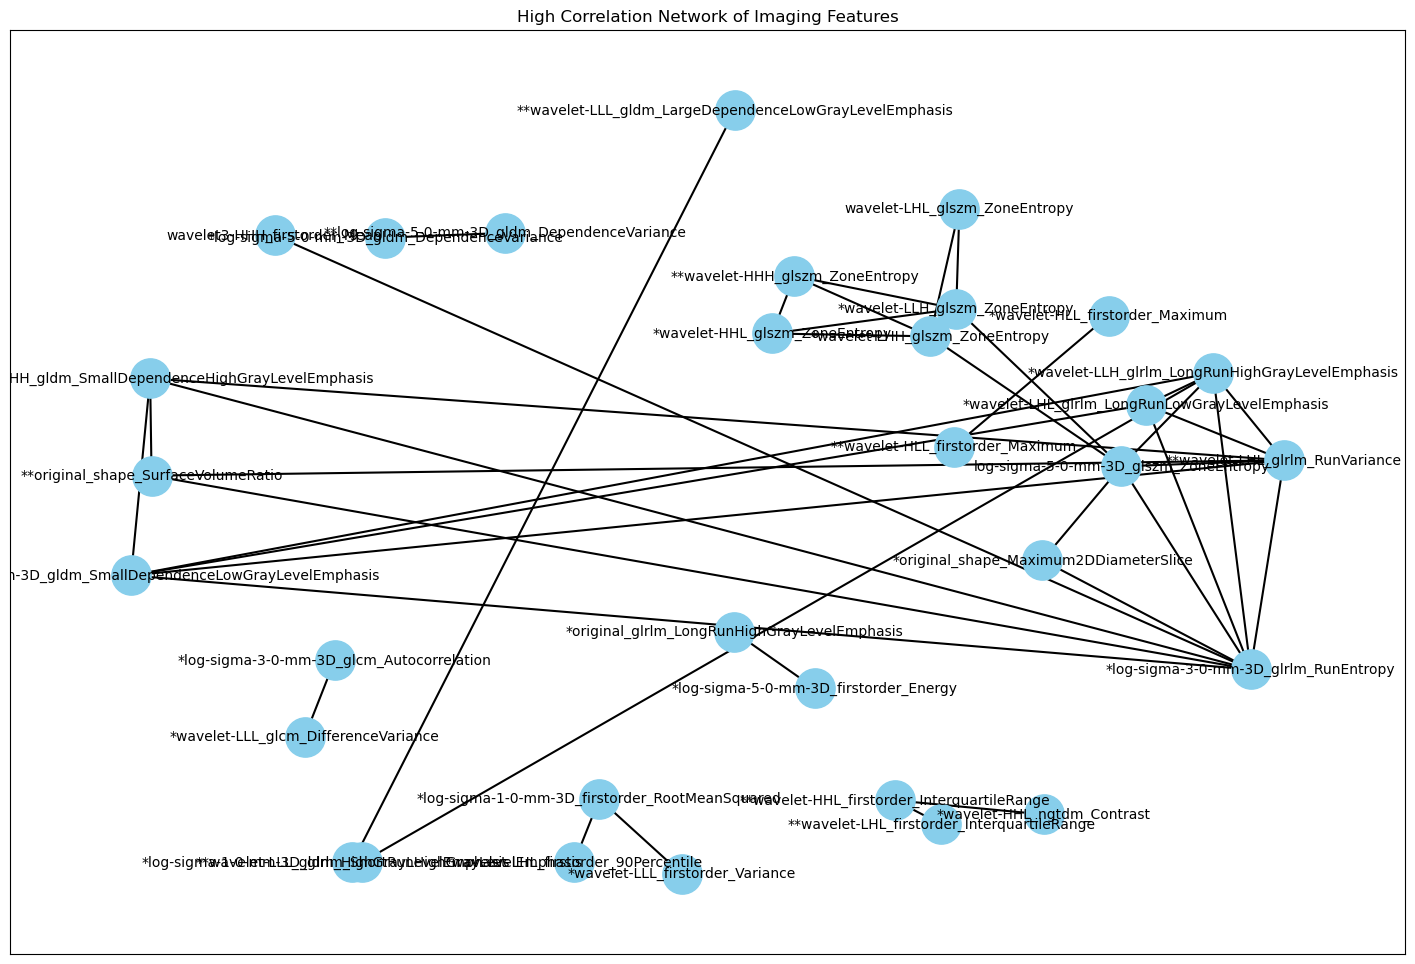

In [89]:
# 筛选r >0.8的特征对
high_corr_pairs = []
cols = corr_matrix.columns
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        if abs(corr_matrix.iloc[i,j]) > 0.7:
            high_corr_pairs.append((cols[i], cols[j], corr_matrix.iloc[i,j]))

print(high_corr_pairs)


import networkx as nx

# 创建网络图对象
G = nx.Graph()
for pair in high_corr_pairs:
    G.add_edge(pair[0], pair[1], weight=pair[2])

# 绘制网络图（过滤弱连接）
plt.figure(figsize=(18,12))
pos = nx.spring_layout(G, k=0.5)  # k控制节点间距
nx.draw_networkx_nodes(G, pos, node_color='skyblue', node_size=800)
nx.draw_networkx_edges(G, pos, edgelist=G.edges(), width=1.5)
nx.draw_networkx_labels(G, pos, font_size=10)
plt.title("High Correlation Network of Imaging Features")
plt.show()


In [90]:
df_weight = pd.concat([pd_weight1, pd_weight2, pd_weight3])

# print(df_weight)

for i in range(len(high_corr_pairs)):
    if high_corr_pairs[i][0] and high_corr_pairs[i][1] in df_weight.columns:
        if df_weight.loc[high_corr_pairs[i][0],0] > df_weight.loc[high_corr_pairs[i][1],0]:
            print(high_corr_pairs[i][1])
            if high_corr_pairs[i][1] in pd_weight1.index:
                pd_weight1 = pd_weight1.drop(high_corr_pairs[i][1])
            elif high_corr_pairs[i][1] in pd_weight2.index:
                pd_weight2 = pd_weight2.drop(high_corr_pairs[i][1])
            elif high_corr_pairs[i][1] in pd_weight3.index:
                pd_weight3 = pd_weight3.drop(high_corr_pairs[i][1])
        else:
            print(high_corr_pairs[i][0])
            if high_corr_pairs[i][0] in pd_weight1.index:
                pd_weight1 = pd_weight1.drop(high_corr_pairs[i][0])
            elif high_corr_pairs[i][0] in pd_weight2.index:
                pd_weight2 = pd_weight2.drop(high_corr_pairs[i][0])
            elif high_corr_pairs[i][0] in pd_weight3.index:
                pd_weight3 = pd_weight3.drop(high_corr_pairs[i][0])

print(pd_weight1.shape, pd_weight2.shape, pd_weight3.shape)

(11, 1) (32, 1) (19, 1)


In [123]:
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from tabpfn import TabPFNClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline  # 必须使用imblearn的Pipeline
from sklearn.model_selection import cross_val_score, RepeatedStratifiedKFold, cross_validate

N_REPEATS = 10  # 重复次数
N_SPLITS = 10   # 每次的折数

clf = TabPFNClassifier(
    random_state = 3407,     
    softmax_temperature=0.85,                # 提高预测锐度
    balance_probabilities=True, 
    memory_saving_mode=True,    
    device='cuda'
)  # 关键改动：添加 device='cuda' 参数

# model_forest = clf.fit(x1_train,y1_train)
model = Pipeline([
    ('sampler', SMOTE(sampling_strategy=0.8, random_state=114514)),  # 自动平衡至多数类数量
    ('classifier', clf)  # 同步启用权重保障
])
# model.fit(x1_train,y1_train)
# score = model.score(x1_test, y1_test)

cv = RepeatedStratifiedKFold(
    n_splits=N_SPLITS,
    n_repeats=N_REPEATS,
    random_state=1028
)

# 评分函数，定义需要计算的指标
scoring = {
    'accuracy': 'accuracy',
    'sensitivity': make_scorer(recall_score),  # 召回率 (Sensitivity)
    'specificity': make_scorer(recall_score, pos_label=0),  # 特异度 (Specificity)，正类为0
    'precision': 'precision',
    'f1': 'f1',
    'auc': 'roc_auc'
}

# 使用cross_validate计算多个评分指标
scores = cross_validate(model, rforest_x, rforest_y, cv=cv, scoring=scoring)

# 打印交叉验证结果
print(f"完成 {N_REPEATS} 次 {N_SPLITS} 折交叉验证")
print("平均准确率: {:.3f} ± {:.3f}".format(np.mean(scores['test_accuracy']), np.std(scores['test_accuracy'])))
print("平均敏感性 (Sensitivity): {:.3f} ± {:.3f}".format(np.mean(scores['test_sensitivity']), np.std(scores['test_sensitivity'])))
print("平均特异性 (Specificity): {:.3f} ± {:.3f}".format(np.mean(scores['test_specificity']), np.std(scores['test_specificity'])))
print("平均精度 (Precision): {:.3f} ± {:.3f}".format(np.mean(scores['test_precision']), np.std(scores['test_precision'])))
print("平均F1分数: {:.3f} ± {:.3f}".format(np.mean(scores['test_f1']), np.std(scores['test_f1'])))
print("平均AUC: {:.3f} ± {:.3f}".format(np.mean(scores['test_auc']), np.std(scores['test_auc'])))

# 将所有的交叉验证结果保存为DataFrame
df_scores = pd.DataFrame({
    'repeat_id': np.repeat(np.arange(N_REPEATS), N_SPLITS),
    'fold_id': np.tile(np.arange(N_SPLITS), N_REPEATS),
    'accuracy': scores['test_accuracy'],
    'sensitivity': scores['test_sensitivity'],
    'specificity': scores['test_specificity'],
    'precision': scores['test_precision'],
    'f1': scores['test_f1'],
    'auc': scores['test_auc']
})

# 保存为CSV（添加元数据标题）
result_path = r'E:\liuzhou_breastcancer\eval_results'
csv_path = os.path.join(result_path, 'val_results_0422.csv')
df_scores.to_csv(csv_path, index=False, header=[
    'RepeatID', 'FoldID', 'Accuracy', 'Sensitivity', 'Specificity', 'Precision', 'F1', 'AUC'
])


model.fit(rforest_x, rforest_y)
#把随机森林的模型保存下来
model_path=r'E:\liuzhou_breastcancer\model'
model_name = 'in_out_sub_1_tabpfn0422.model'
if not os.path.exists(model_path):
    os.makedirs(model_path)
joblib.dump(model, model_path+'/'+model_name)

完成 10 次 10 折交叉验证
平均准确率: 0.946 ± 0.023
平均敏感性 (Sensitivity): 0.961 ± 0.023
平均特异性 (Specificity): 0.907 ± 0.064
平均精度 (Precision): 0.964 ± 0.024
平均F1分数: 0.962 ± 0.016
平均AUC: 0.986 ± 0.010


['E:\\liuzhou_breastcancer\\model/in_out_sub_1_tabpfn0422.model']

In [120]:
import joblib
index1 = pd_weight1.index
x1_test_data = pd.DataFrame(X1_test.loc[:,index1])
index2 = pd_weight2.index
x2_test_data = pd.DataFrame(X2_test.loc[:,index2])
index3 = pd_weight3.index
x3_test_data = pd.DataFrame(X3_test.loc[:,index3])

x_test_data = pd.concat([x1_test_data,x2_test_data,x3_test_data],axis=1)
columnNames = x_test_data.columns
x_test_data = x_test_data.astype(np.float32)

print(x_test_data.shape)
print(rforest_x.shape)
x_test_data = standardscaler.transform(x_test_data) #均值-标准差归一化
x_test_data = pd.DataFrame(x_test_data,columns=columnNames)
y_test_data = pd.DataFrame(y_test)

print("测试集一共有{}行特征数据，{}列不同特征".format(len(x_test_data),x_test_data.shape[1]))
#加载保存后的模型，然后进行预测


model_forest = joblib.load(model_path+'/'+model_name) #这是自己训练模型，记得替换自己的。
score = model_forest.score(x_test_data, y_test_data)
print("在测试集上的准确率：{}".format(score))

(326, 62)
(758, 62)
测试集一共有326行特征数据，62列不同特征
在测试集上的准确率：0.9141104294478528


In [121]:
import joblib
from sklearn.metrics import classification_report, confusion_matrix
# index = pd_weight.index
# x_test_data = pd.DataFrame(X_test.loc[:,index])
model_name = 'in_out_sub_1_tabpfn0422.model'

columnNames = x_test_data.columns
x_test_data = x_test_data.astype(np.float32)
x_test_data = pd.DataFrame(x_test_data,columns=columnNames)
y_test_data = pd.DataFrame(y_test)

print("测试集一共有{}行特征数据，{}列不同特征".format(len(x_test_data),x_test_data.shape[1]))
#加载保存后的模型，然后进行预测


model_forest = joblib.load(model_path+'/'+model_name) #这是自己训练模型，记得替换自己的。
score = model_forest.score(x_test_data, y_test_data)
print("在测试集上的准确率：{}".format(score))

# 计算其他评估指标
# 分类报告：包括 Precision, Recall (Sensitivity), F1-score
y_pred = model_forest.predict(x_test_data)
print("\n分类报告：")
print(classification_report(y_test_data, y_pred))

precision = precision_score(y_test_data, y_pred)
recall = recall_score(y_test_data, y_pred)
f1 = f1_score(y_test_data, y_pred)
# 混淆矩阵：用于计算 Specificity 和 Sensitivity
conf_matrix = confusion_matrix(y_test_data, y_pred)
tn, fp, fn, tp = conf_matrix.ravel()

# Sensitivity（召回率） = TP / (TP + FN)
sensitivity = tp / (tp + fn)
# Specificity = TN / (TN + FP)
specificity = tn / (tn + fp)

# AUC (ROC曲线下的面积)
y_prob = model_forest.predict_proba(x_test_data)[:, 1]  # 获取正类的概率
auc_score = roc_auc_score(y_test_data, y_prob)

# 输出结果
print("\n整体结果:")
print(f"Sensitivity (召回率): {sensitivity:.4f}")
print(f"Specificity (特异性): {specificity:.4f}")
print(f"Precision (精确率): {precision:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"AUC: {auc_score:.4f}")

# 创建一个包含实际类别和预测概率的 DataFrame
result_df = pd.DataFrame({
    'Actual': y_test_data.values.flatten(),  # 真实标签
    'Predicted_Prob': y_prob  # 预测的正类概率
})

# 保存为 CSV 文件
res_path = r"E:\liuzhou_breastcancer\test_result"
result_df.to_csv( res_path + r'\in_out_sub_1_0427.csv', index=False)
print("预测概率和实际标签已保存至 'in_out_sub_1_0427.csv'")

测试集一共有326行特征数据，62列不同特征
在测试集上的准确率：0.9141104294478528

分类报告：
              precision    recall  f1-score   support

           0       0.86      0.84      0.85        93
           1       0.94      0.94      0.94       233

    accuracy                           0.91       326
   macro avg       0.90      0.89      0.89       326
weighted avg       0.91      0.91      0.91       326


整体结果:
Sensitivity (召回率): 0.9442
Specificity (特异性): 0.8387
Precision (精确率): 0.9362
F1-score: 0.9402
AUC: 0.9573
预测概率和实际标签已保存至 'in_out_sub_1_0427.csv'


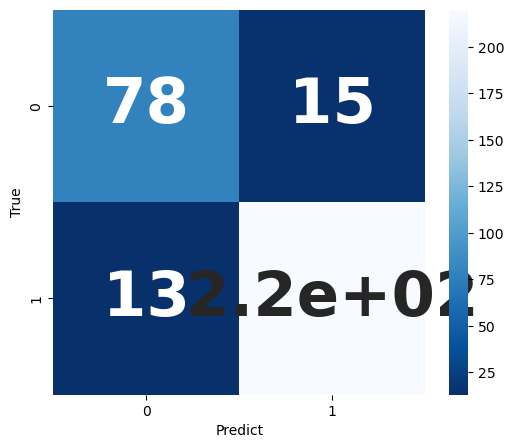

混淆矩阵为：
[[ 78  15]
 [ 13 220]]

计算各项指标：
              precision    recall  f1-score   support

           0       0.86      0.84      0.85        93
           1       0.94      0.94      0.94       233

    accuracy                           0.91       326
   macro avg       0.90      0.89      0.89       326
weighted avg       0.91      0.91      0.91       326



In [122]:
#绘制混淆矩阵
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import seaborn as sns
from sklearn.metrics import confusion_matrix

predict_label = model_forest.predict(x_test_data) # 预测的标签
label = y_test_data.values.tolist()  # 真实标签
confusion = confusion_matrix(label, predict_label) # 计算混淆矩阵

plt.figure(figsize=(6, 5))
sns.heatmap(confusion, cmap='Blues_r', annot=True, annot_kws={'size': 45, 'weight': 'bold'}) # 绘制混淆矩阵
plt.xlabel('Predict')
plt.ylabel('True')
plt.show()

print("混淆矩阵为：\n{}".format(confusion))
print("\n计算各项指标：")
print(classification_report(label, predict_label))


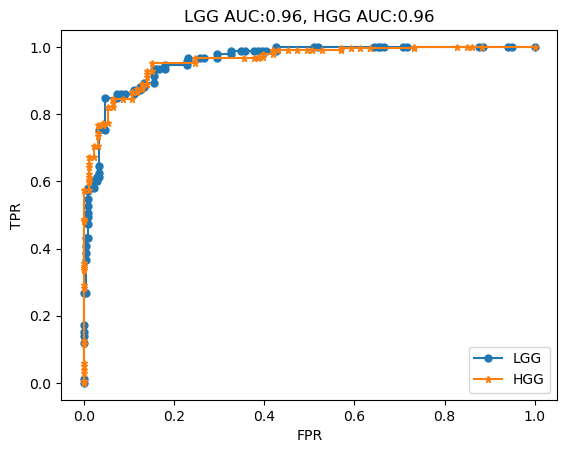

In [25]:
#绘制ROC曲线,方法1
from sklearn.metrics import roc_curve, roc_auc_score,auc
kind = {'HGG':1,"LGG":0}
model_forest = joblib.load(model_path+'/'+model_name)#这是自己训练模型，记得替换自己的
label = y_test_data.values.tolist()  #真实标签
y_predict = model_forest.predict_proba(x_test_data)#得到标签0和1对应的概率h
fpr , tpr ,threshold = roc_curve(label, y_predict[:,kind['LGG']], pos_label=kind['LGG'])
roc_auc = auc(fpr,tpr) #计算auc的
fpr1 , tpr1 ,threshold = roc_curve(label, y_predict[:,kind['HGG']], pos_label=kind['HGG'])
roc_auc1 = auc(fpr1,tpr1) #计算auc的
plt.plot(fpr, tpr,marker='o', markersize=5,label='LGG')
plt.plot(fpr1, tpr1,marker='*', markersize=5,label='HGG')
plt.title("LGG AUC:{:.2f}, HGG AUC:{:.2f}".format(roc_auc,roc_auc1))
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend(loc=4)
plt.show()

In [35]:
# Code source: Gaël Varoquaux
#              Andreas Müller
# Modified for documentation by Jaques Grobler
# License: BSD 3 clause

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.datasets import make_moons, make_circles, make_classification
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.inspection import DecisionBoundaryDisplay
import warnings


names = [
    "Nearest Neighbors",
    "Linear SVM",
    "RBF SVM",
    "Gaussian Process",
    "Decision Tree",
    "Random Forest",
    "Neural Net",
    "AdaBoost",
    "Naive Bayes",
    "QDA",
]
seed=4
classifiers = [
    KNeighborsClassifier(2),
    SVC(kernel="linear", C=0.025,probability=True,random_state=seed),
    SVC(gamma=2, C=1,probability=True,random_state=seed),
    GaussianProcessClassifier(1.0 * RBF(1.0),random_state=seed),
    DecisionTreeClassifier(max_depth=5,random_state=seed),
    RandomForestClassifier(max_depth=5, n_estimators=100, max_features=10,random_state=seed),
    MLPClassifier(alpha=1, max_iter=1000,random_state=seed),
    AdaBoostClassifier(random_state=seed),
    GaussianNB(),
    QuadraticDiscriminantAnalysis(),
]

for name, clf in zip(names, classifiers):
    clf = make_pipeline(StandardScaler(), clf)
    clf.fit(rforest_x, rforest_y)
    pred_y= clf.predict(x_test_data)
    pred_y_proba = clf.predict_proba(x_test_data)
    accuracy=metrics.accuracy_score(y_test_data,pred_y)
    balanced_accuracy=metrics.balanced_accuracy_score(y_test_data,pred_y)
    f1_weighted=metrics.f1_score(y_test_data,pred_y)
    precision=metrics.precision_score(y_test_data,pred_y)
    sensitivity=metrics.precision_score(y_test_data,pred_y)
    tn,fp,fn,tp=confusion_matrix(y_test_data,pred_y).ravel()
    specificity=tn/(tn+fp)
    AUC=metrics.roc_auc_score(y_test_data,pred_y_proba[:,-1])
    print(name+'\n'+'accuracy: '+str(accuracy)[:6]
          +', sensitivity: '+str(sensitivity)[:6]
          +', specificity: '+str(specificity)[:6]
          +', precision: '+str(precision)[:6]
          +', f1_weighted: '+str(f1_weighted)[:6]
          +', AUC: '+str(AUC)[:6])
    # print(pred_y)
    # break
    # print(name+' '+str(score))

Nearest Neighbors
accuracy: 0.8181, sensitivity: 0.904, specificity: 0.8481, precision: 0.904, f1_weighted: 0.8496, AUC: 0.8635
Linear SVM
accuracy: 0.8590, sensitivity: 0.8481, specificity: 0.6962, precision: 0.8481, f1_weighted: 0.8963, AUC: 0.9157
RBF SVM
accuracy: 0.8454, sensitivity: 0.8057, specificity: 0.5696, precision: 0.8057, f1_weighted: 0.8924, AUC: 0.9029
Gaussian Process
accuracy: 0.6409, sensitivity: 0.6409, specificity: 0.0, precision: 0.6409, f1_weighted: 0.7811, AUC: 0.8712
Decision Tree
accuracy: 0.8045, sensitivity: 0.8450, specificity: 0.7215, precision: 0.8450, f1_weighted: 0.8480, AUC: 0.7891
Random Forest
accuracy: 0.8681, sensitivity: 0.8733, specificity: 0.7594, precision: 0.8733, f1_weighted: 0.9003, AUC: 0.9197
Neural Net
accuracy: 0.8681, sensitivity: 0.8943, specificity: 0.8101, precision: 0.8943, f1_weighted: 0.8975, AUC: 0.9296
AdaBoost
accuracy: 0.8909, sensitivity: 0.9333, specificity: 0.8860, precision: 0.9333, f1_weighted: 0.9130, AUC: 0.9201
Naive B

In [ ]:
index = pd_weight.index
rforest_x = X_train.loc[:,index]
rforest_x['label']=y_train
rforest_x.to_csv('model_data/train.csv')
x_test_data = X_test.loc[:,index]
x_test_data['label']=y_test_data
x_test_data.to_csv('model_data/test.csv')